# MNase-seq Replicate 1 60 minute Alignment Check

Notebook to check if the alignment for replicate 1 60 minute MNase-seq data was done correctly.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [73]:
from cc_src.read_bam import read_mnase_bam
from cc_src.sgd import get_chromosome_length

def get_sliding_window_counts(mnase_reads, chrom_len):
    from cc_src.mnase_replication_timing_analysis import compute_sliding_window

    bins = np.arange(0, chrom_len)
    counts, _ = np.histogram(mnase_reads['mid'], bins=bins)
    window_size = 10000
    step = 2000
    sliding_window_counts = compute_sliding_window(counts, window_size, step)
    return sliding_window_counts.sum(axis=1)

def plot_chrom_comparison(chrom):
    
    chrom_len = get_chromosome_length(chrom)
    
    filename = ('/Users/trung/Research/_archive/data/bam/cell_cycle/mnase/DMAH70_MNase_rep1_60_min.bam')
    mnase_bam_original = read_mnase_bam(filename, sample='60_original', chroms=[chrom])
    sliding_counts_original = get_sliding_window_counts(mnase_bam_original, chrom_len)

    filename = ('/Users/trung/Research/_archive/data/bam/cell_cycle/mnase_realign/'
                'DMAH70_sacCer3_m1_2024-03-13-09-50_sorted.bam')

    mnase_bam_realigned = read_mnase_bam(filename, sample='60_realigned', chroms=[chrom])
    sliding_counts_realigned = get_sliding_window_counts(mnase_bam_realigned, chrom_len)

    fig = plt.figure(figsize=(13, 3))
    plt.subplot(2, 1, 1)
    plt.plot(sliding_counts_original, label="Original")
    plt.plot(sliding_counts_realigned, label="Realigned")
    plt.title(f"Replicate 1, Chr{chrom}, MNase-seq reads (Window: 10k, Step: 2k)")
    plt.legend()
    
    return sliding_counts_original, sliding_counts_original

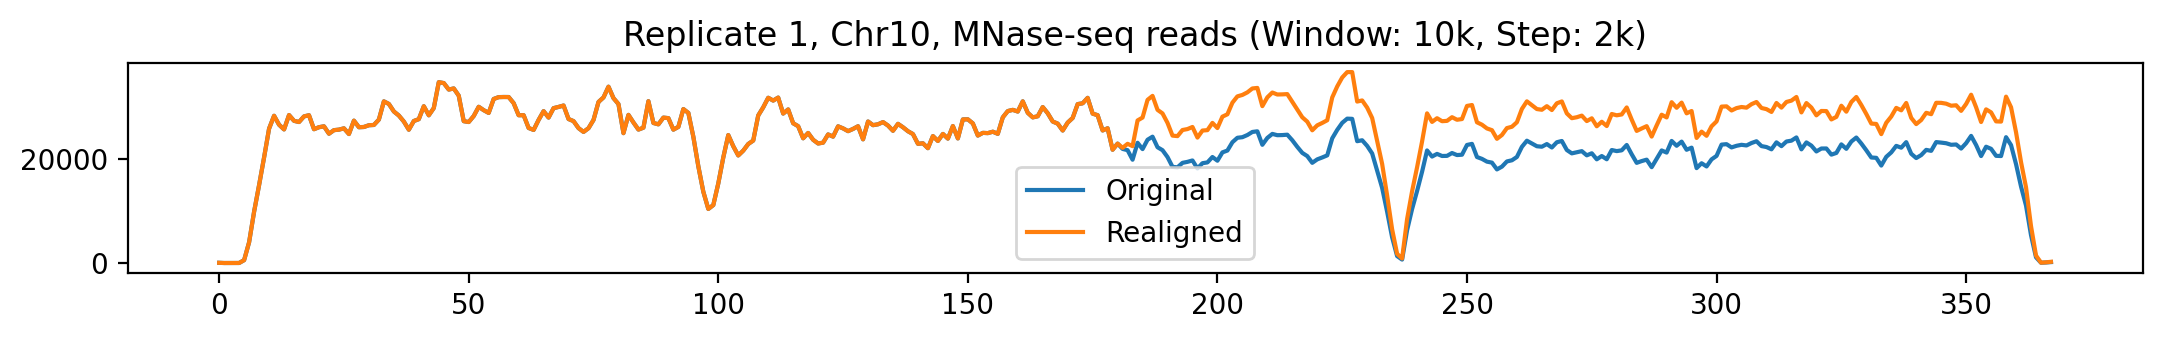

In [74]:
_ = plot_chrom_comparison(10)

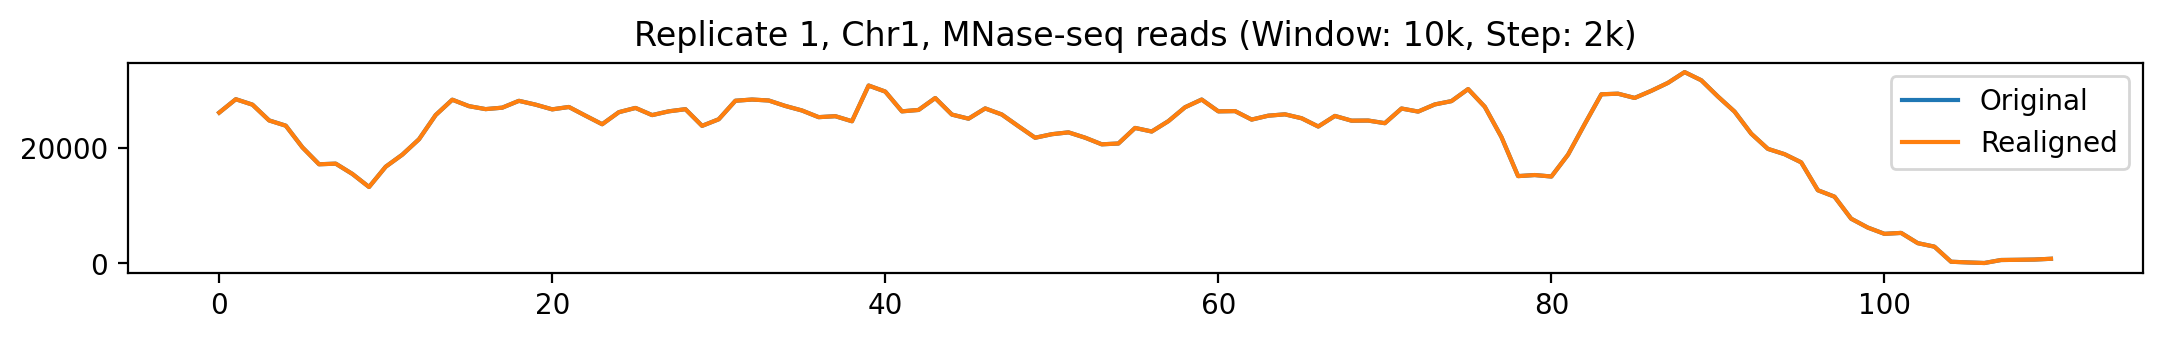

In [75]:
_ = plot_chrom_comparison(1)

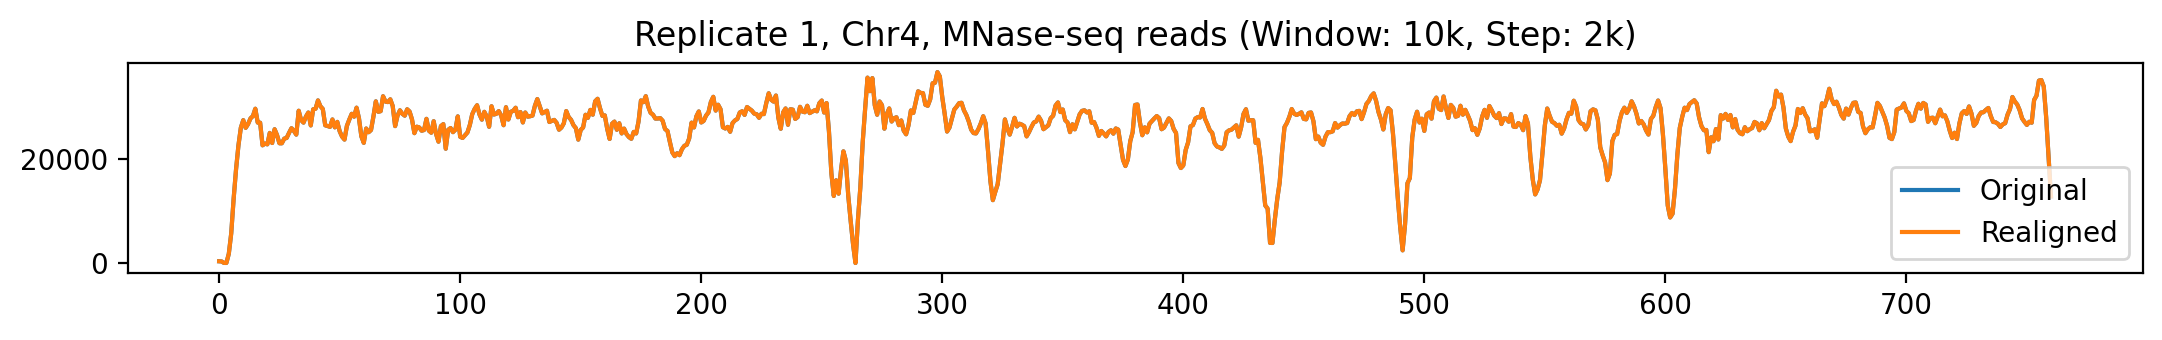

In [96]:
_ = plot_chrom_comparison(4)

In [80]:

from src.timer import Timer

timer = Timer()

filename = ('/Users/trung/Research/_archive/data/bam/cell_cycle/mnase/DMAH70_MNase_rep1_60_min.bam')
mnase_bam_original = read_mnase_bam(filename, sample='60_original', timer=timer,
                                   log=True)

filename = ('/Users/trung/Research/_archive/data/bam/cell_cycle/mnase_realign/'
        'DMAH70_sacCer3_m1_2024-03-13-09-50_sorted.bam')
mnase_bam_realigned = read_mnase_bam(filename, sample='60_realigned', timer=timer,
                                    log=True)

Chromosome 1 - 00:00:00.002
Chromosome 2 - 00:00:00.885
Chromosome 3 - 00:00:04.568
Chromosome 4 - 00:00:05.965
Chromosome 5 - 00:00:12.819
Chromosome 6 - 00:00:15.544
Chromosome 7 - 00:00:16.740
Chromosome 8 - 00:00:21.614
Chromosome 9 - 00:00:24.044
Chromosome 10 - 00:00:25.942
Chromosome 11 - 00:00:28.747
Chromosome 12 - 00:00:31.072
Chromosome 13 - 00:00:35.574
Chromosome 14 - 00:00:38.653
Chromosome 15 - 00:00:41.180
Chromosome 16 - 00:00:44.928
Chromosome 1 - 00:01:26.382
Chromosome 2 - 00:01:27.208
Chromosome 3 - 00:01:30.746
Chromosome 4 - 00:01:32.103
Chromosome 5 - 00:01:38.645
Chromosome 6 - 00:01:41.238
Chromosome 7 - 00:01:42.404
Chromosome 8 - 00:01:47.191
Chromosome 9 - 00:01:49.598
Chromosome 10 - 00:01:51.557
Chromosome 11 - 00:01:54.910
Chromosome 12 - 00:01:58.042
Chromosome 13 - 00:02:04.224
Chromosome 14 - 00:02:08.541
Chromosome 15 - 00:02:11.955
Chromosome 16 - 00:02:16.927


In [94]:
len_bins = np.arange(0, 250)
len_counts_orig, _ = np.histogram(mnase_bam_original['length'], bins=len_bins)

len_bins = np.arange(0, 250)
len_counts_realigned, _ = np.histogram(mnase_bam_realigned['length'], bins=len_bins)


Text(0.5, 1.0, 'Length distribution')

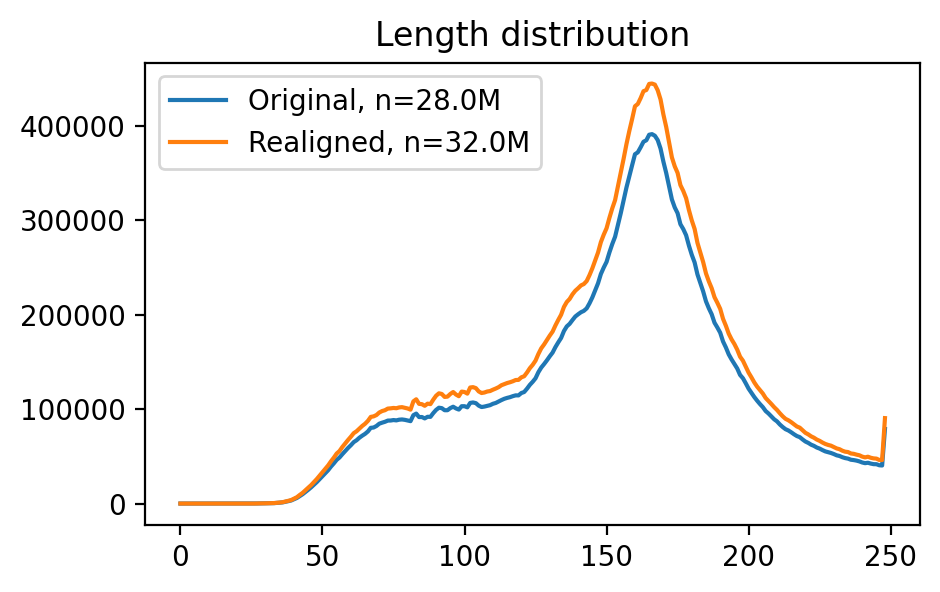

In [102]:
plt.figure(figsize=(5, 3))
plt.plot(len_counts_orig, label=f"Original, n={len(mnase_bam_original)//1e6}M")
plt.plot(len_counts_realigned, label=f"Realigned, n={len(mnase_bam_realigned)//1e6}M")
plt.legend()
plt.title("Length distribution")